In [1]:
import os, pandas as pd, numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
import os, sys
import time

In [2]:
print(f"Python version: {sys.version}")
print(f"NumPy version:  {np.__version__}")
print(f"Pandas version: {pd.__version__}")

Python version: 3.10.20 | packaged by conda-forge | (main, Mar  5 2026, 17:06:34) [Clang 19.1.7 ]
NumPy version:  2.2.6
Pandas version: 2.3.3


In [3]:
import pltfont # mac 전용 한글 깨짐 라이브러리

# 데이터 불러오기

In [4]:
df_raw =pd.read_csv("/Users/jun/GitStudy/human_A/data/dabin.csv")

# 데이터 상태 확인

In [5]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43200 entries, 0 to 43199
Data columns (total 50 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   timestamp                     43200 non-null  object 
 1   light_ppfd_umol_m2_s          43200 non-null  float64
 2   air_temp_c                    43200 non-null  float64
 3   relative_humidity_pct         43200 non-null  float64
 4   co2_ppm                       43200 non-null  float64
 5   raw_tank_level_pct            43200 non-null  float64
 6   raw_water_temp_c              43200 non-null  float64
 7   pump_rpm                      43200 non-null  float64
 8   flow_baseline_l_min           43200 non-null  float64
 9   flow_rate_l_min               43200 non-null  float64
 10  suction_pressure_kpa          43200 non-null  float64
 11  discharge_pressure_kpa        43200 non-null  float64
 12  motor_current_a               43200 non-null  float64
 13  m

In [6]:
df_raw.describe()

,light_ppfd_umol_m2_s,air_temp_c,relative_humidity_pct,co2_ppm,raw_tank_level_pct,raw_water_temp_c,pump_rpm,flow_baseline_l_min,flow_rate_l_min,suction_pressure_kpa,...,zone2_substrate_ec_ds_m,zone2_substrate_ph,zone3_flow_l_min,zone3_pressure_kpa,zone3_substrate_moisture_pct,zone3_substrate_ec_ds_m,zone3_substrate_ph,cleaning_event_flag,hidden_tip_clog_level,hidden_blocked_tip_ratio
count,43200.000000,43200.000000,43200.000000,43200.000000,43200.000000,43200.000000,43200.000000,43200.000000,43200.000000,43200.000000,...,43200.000000,43200.000000,43200.000000,43200.000000,43200.000000,43200.000000,43200.000000,43200.000000,43200.000000,43200.000000
mean,253.308171,23.227978,72.592542,734.550344,51.176212,19.385609,1752.192652,77.998950,76.522275,-10.611168,...,2.131203,5.816424,24.526406,88.279206,60.261134,2.137611,5.815913,0.002778,0.176122,0.083046
std,258.970295,2.259637,7.964207,33.059195,11.502972,1.136495,10.104609,1.471826,2.174290,0.242307,...,0.044479,0.018621,1.086981,2.226769,1.647988,0.048514,0.018635,0.052632,0.112154,0.101648
min,0.000000,19.000000,54.520000,639.290000,40.000000,17.300000,1723.760000,74.510000,70.300000,-11.840000,...,1.990000,5.753000,21.590000,83.460000,55.980000,1.975000,5.749000,0.000000,0.000000,0.000000
25%,39.660000,21.550000,64.610000,705.070000,40.000000,18.490000,1746.290000,76.650000,75.080000,-10.700000,...,2.099000,5.803000,23.760000,86.530000,59.160000,2.102000,5.802000,0.000000,0.078300,0.000000
50%,73.205000,22.320000,76.820000,746.040000,48.080000,19.080000,1750.580000,78.000000,76.520000,-10.580000,...,2.129000,5.816000,24.680000,87.790000,60.300000,2.134000,5.816000,0.000000,0.169400,0.000000
75%,512.460000,25.370000,79.380000,761.110000,61.020000,20.370000,1755.160000,79.360000,78.150000,-10.460000,...,2.161000,5.830000,25.350000,89.770000,61.080000,2.171000,5.830000,0.000000,0.264000,0.200000
max,764.620000,28.280000,83.430000,805.190000,75.180000,22.190000,1801.170000,81.530000,82.890000,-9.900000,...,2.298000,5.882000,27.650000,98.550000,66.950000,2.312000,5.877000,1.000000,0.374500,0.300000


#### 데이터 형 변환

In [7]:
# 타임스탬프 데이터타입으로 변환
df_raw["timestamp"] = pd.to_datetime(df_raw['timestamp'])

In [8]:
# 'id' 컬럼을 인덱스(PK 역할)로 설정
df_raw = df_raw.set_index('timestamp')

# 결측치 확인 

In [9]:
df_raw[df_raw.isnull()].count()

light_ppfd_umol_m2_s            0
air_temp_c                      0
relative_humidity_pct           0
co2_ppm                         0
raw_tank_level_pct              0
raw_water_temp_c                0
pump_rpm                        0
flow_baseline_l_min             0
flow_rate_l_min                 0
suction_pressure_kpa            0
discharge_pressure_kpa          0
motor_current_a                 0
motor_power_kw                  0
bearing_vibration_rms_mm_s      0
motor_temperature_c             0
bearing_temperature_c           0
filter_pressure_in_kpa          0
filter_pressure_out_kpa         0
turbidity_ntu                   0
mix_target_ec_ds_m              0
mix_ec_ds_m                     0
mix_target_ph                   0
mix_ph                          0
mix_temp_c                      0
mix_flow_l_min                  0
dosing_acid_ml_min              0
drain_ec_ds_m                   0
tank_a_level_pct                0
tank_b_level_pct                0
acid_tank_leve

In [10]:
df_raw[df_raw.isnull()].count().values

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0])

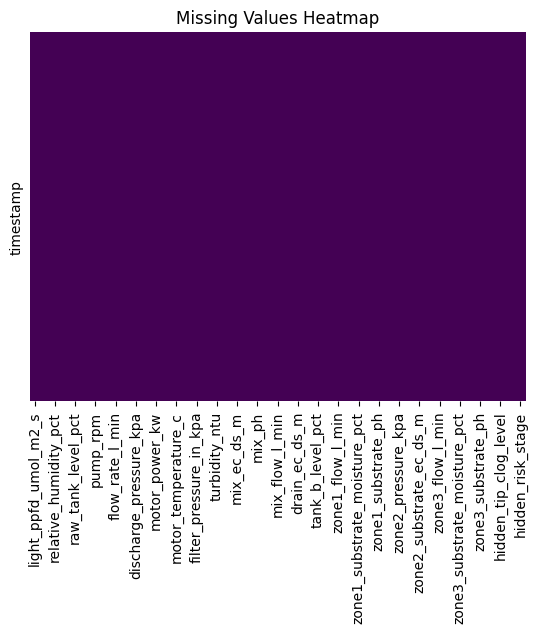

In [11]:
sns.heatmap(df_raw.isnull(), cbar=False, yticklabels=False, cmap='viridis')

plt.title('Missing Values Heatmap')
plt.show()

# 데이터 상관관계 확인

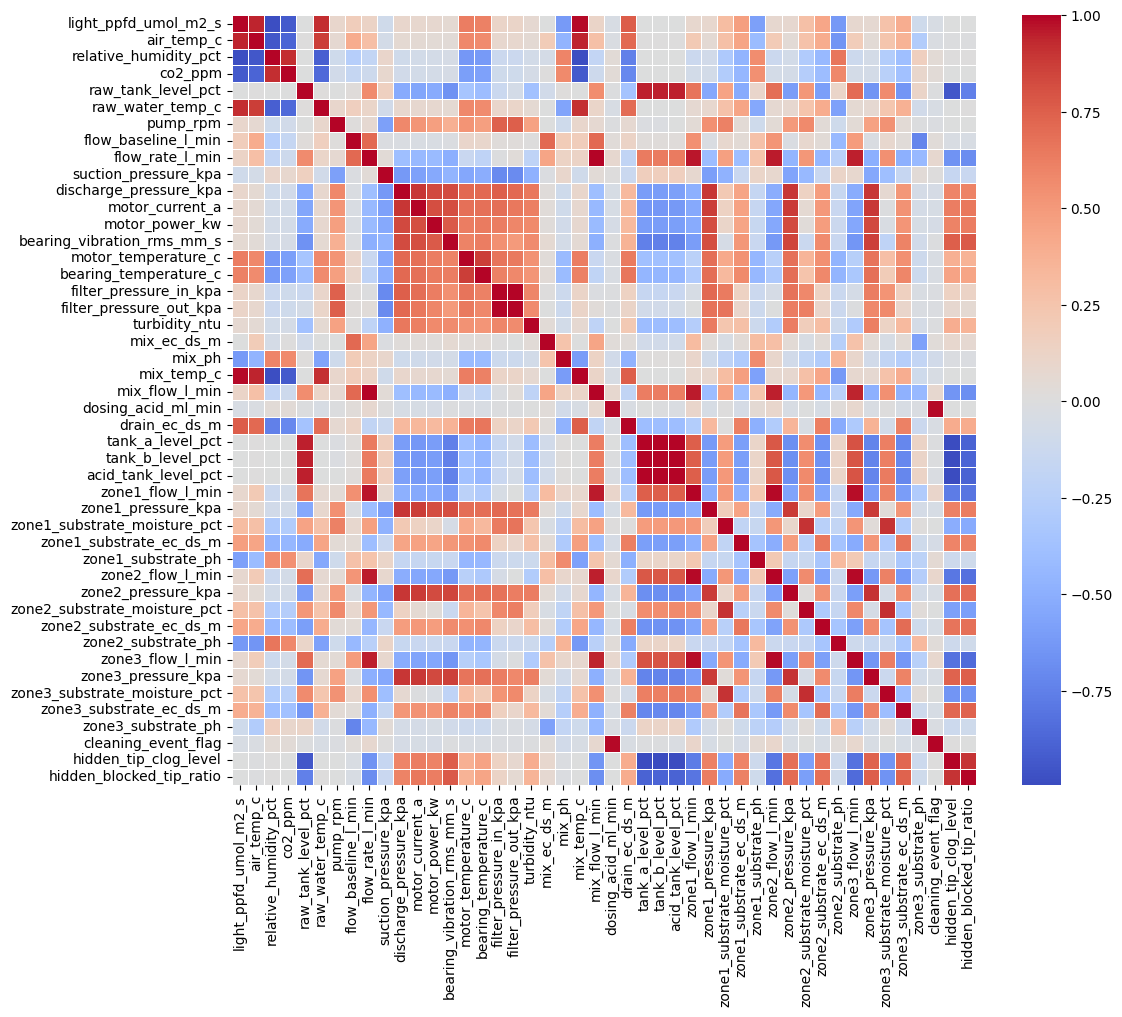

In [12]:
# 상관계수 계산
corr = df_raw.corr(numeric_only=True)

# 특정 기준(예: 상관계수 0.5) 이상의 관계가 하나라도 있는 컬럼만 추출
threshold = 0.5
high_corr_cols = corr.columns[(corr.abs() > threshold).any()]
filtered_corr = corr.loc[high_corr_cols, high_corr_cols]

plt.figure(figsize=(12, 10))
sns.heatmap(filtered_corr, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.show()

In [13]:
# 2. 전체 상관계수 계산 (숫자형 + 수치화된 범주형)
corr_matrix = df_raw.corr(numeric_only=True).abs()

# 3. 상삼각 행렬만 추출
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

In [14]:
threshold = 0.7
high_corr_pairs = np.where(upper > threshold)

# 쌍(Pair) 리스트 생성
pairs = [(upper.index[i], upper.columns[j], upper.iloc[i, j]) 
        for i, j in zip(*high_corr_pairs)]

# 그룹화 (Dictionary 활용)
groups = {}
for p1, p2, val in pairs:
    if p1 not in groups: groups[p1] = []
    groups[p1].append(f"{p2}({val:.2f})")

print(f"--- [상관계수 {threshold} 이상] 연관 변수 그룹 ---")
if not groups:
    print("기준치를 넘는 고상관 변수가 없습니다.")
else:
    for key, values in groups.items():
        print(f"[{key}] 변수와 중복 위험: {', '.join(values)}\n")

--- [상관계수 0.7 이상] 연관 변수 그룹 ---
[light_ppfd_umol_m2_s] 변수와 중복 위험: air_temp_c(0.94), relative_humidity_pct(0.98), co2_ppm(0.93), raw_water_temp_c(0.91), mix_temp_c(0.99), drain_ec_ds_m(0.76)

[air_temp_c] 변수와 중복 위험: relative_humidity_pct(0.95), co2_ppm(0.88), raw_water_temp_c(0.87), mix_temp_c(0.94), drain_ec_ds_m(0.72)

[relative_humidity_pct] 변수와 중복 위험: co2_ppm(0.92), raw_water_temp_c(0.90), mix_temp_c(0.98), drain_ec_ds_m(0.75)

[co2_ppm] 변수와 중복 위험: raw_water_temp_c(0.86), mix_temp_c(0.93), drain_ec_ds_m(0.71)

[raw_tank_level_pct] 변수와 중복 위험: tank_a_level_pct(0.95), tank_b_level_pct(0.95), acid_tank_level_pct(0.95), zone3_flow_l_min(0.71), hidden_tip_clog_level(0.94), hidden_blocked_tip_ratio(0.75)

[raw_water_temp_c] 변수와 중복 위험: mix_temp_c(0.91), drain_ec_ds_m(0.70)

[pump_rpm] 변수와 중복 위험: filter_pressure_in_kpa(0.75), filter_pressure_out_kpa(0.75)

[flow_baseline_l_min] 변수와 중복 위험: flow_rate_l_min(0.72), mix_ec_ds_m(0.71), mix_flow_l_min(0.71), zone3_substrate_ph(0.72)

[flow_rate_l_mi

In [15]:
compare_groups = {
    # 1. 구역별 양액 공급 균일도 체크
    "Flow Rate Comparison (Zone 1 vs 2 vs 3)": [
        "zone1_flow_l_min", "zone2_flow_l_min", "zone3_flow_l_min", "mix_flow_l_min"
    ],
    # 2. 구역별 관수 압력 편차 (노즐 막힘 확인용)
    "Pressure Comparison (Zone 1 vs 2 vs 3)": [
        "zone1_pressure_kpa", "zone2_pressure_kpa", "zone3_pressure_kpa"
    ],
    # 3. 양액 산도 변화 (원천-혼합-배지)
    "pH Comparison (Mix vs Substrate)": [
        "mix_target_ph", "mix_ph", "zone1_substrate_ph", "zone2_substrate_ph", "zone3_substrate_ph"
    ],
    # 4. 양액 농도 변화 (혼합-배지-배액)
    "EC Comparison (Mix vs Substrate vs Drain)": [
        "mix_target_ec_ds_m", "mix_ec_ds_m", "drain_ec_ds_m", 
        "zone1_substrate_ec_ds_m", "zone2_substrate_ec_ds_m", "zone3_substrate_ec_ds_m"
    ],
    # 5. 온도 상관관계 (기온-양액-모터)
    "Temperature Comparison": [
        "air_temp_c", "mix_temp_c", "raw_water_temp_c", "motor_temperature_c", "bearing_temperature_c"
    ],
    # 6. 저장탱크 잔량 (공급 원료 모니터링)
    "Tank Levels": [
        "raw_tank_level_pct", "tank_a_level_pct", "tank_b_level_pct", "acid_tank_level_pct"
    ],
    # 7. 펌프 및 필터 압력 계통 (예지보전 핵심)
    "System Pressure": [
        "filter_pressure_in_kpa", "filter_pressure_out_kpa", 
        "suction_pressure_kpa", "discharge_pressure_kpa"
    ],
    # 8. 모터 부하 및 상태 모니터링
    "Motor & Pump Health": [
        "pump_rpm", "motor_current_a", "motor_power_kw", "bearing_vibration_rms_mm_s"
    ],
    # 9. 생육 환경 및 리스크 지표
    "Environment & Hidden Risks": [
        "light_ppfd_umol_m2_s", "co2_ppm", "relative_humidity_pct", 
        "hidden_tip_clog_level", "hidden_blocked_tip_ratio", "hidden_risk_stage"
    ]
}

In [16]:
df_raw.columns

Index(['light_ppfd_umol_m2_s', 'air_temp_c', 'relative_humidity_pct',
       'co2_ppm', 'raw_tank_level_pct', 'raw_water_temp_c', 'pump_rpm',
       'flow_baseline_l_min', 'flow_rate_l_min', 'suction_pressure_kpa',
       'discharge_pressure_kpa', 'motor_current_a', 'motor_power_kw',
       'bearing_vibration_rms_mm_s', 'motor_temperature_c',
       'bearing_temperature_c', 'filter_pressure_in_kpa',
       'filter_pressure_out_kpa', 'turbidity_ntu', 'mix_target_ec_ds_m',
       'mix_ec_ds_m', 'mix_target_ph', 'mix_ph', 'mix_temp_c',
       'mix_flow_l_min', 'dosing_acid_ml_min', 'drain_ec_ds_m',
       'tank_a_level_pct', 'tank_b_level_pct', 'acid_tank_level_pct',
       'zone1_flow_l_min', 'zone1_pressure_kpa',
       'zone1_substrate_moisture_pct', 'zone1_substrate_ec_ds_m',
       'zone1_substrate_ph', 'zone2_flow_l_min', 'zone2_pressure_kpa',
       'zone2_substrate_moisture_pct', 'zone2_substrate_ec_ds_m',
       'zone2_substrate_ph', 'zone3_flow_l_min', 'zone3_pressure_kpa',
    

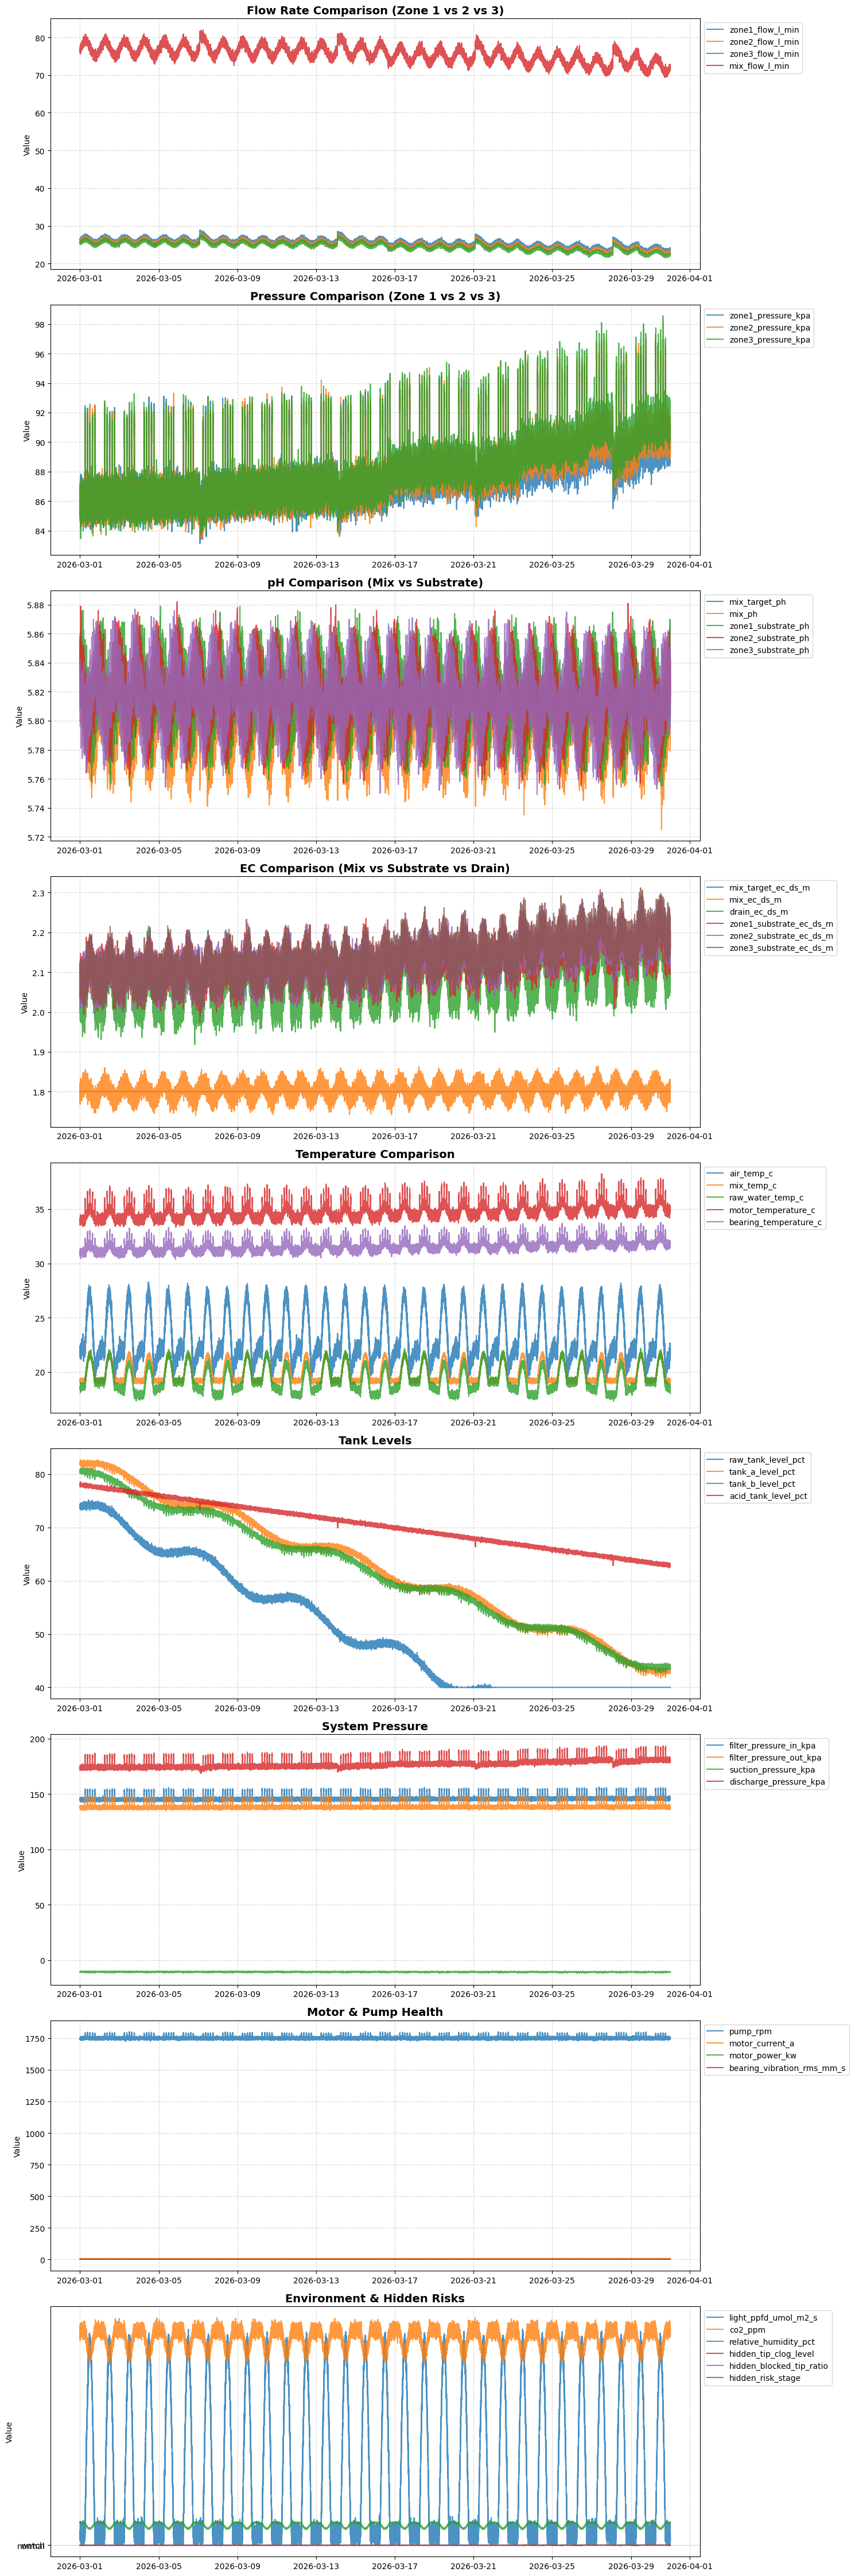

In [17]:
# 시각화 설정
n_groups = len(compare_groups)
fig, axes = plt.subplots(n_groups, 1, figsize=(15, 5 * n_groups))


# 데이터가 너무 많으면 그래프가 무거우니 하루 정도만 샘플링해서 보기
# 10분 간격, 60분, 24시간 이니까  = 6*24
plot_df = df_raw.iloc[:] 
#plot_df = df_raw

for i, (title, cols) in enumerate(compare_groups.items()):
    ax = axes[i]
    
    # 존재하는 컬럼만 그리기
    valid_cols = [c for c in cols if c in plot_df.columns]
    
    for col in valid_cols:
        ax.plot(plot_df.index, plot_df[col], label=col, alpha=0.8, linewidth=1.5)
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1)) # 범례를 그래프 밖에 표시
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_ylabel("Value")

plt.tight_layout()
plt.show()

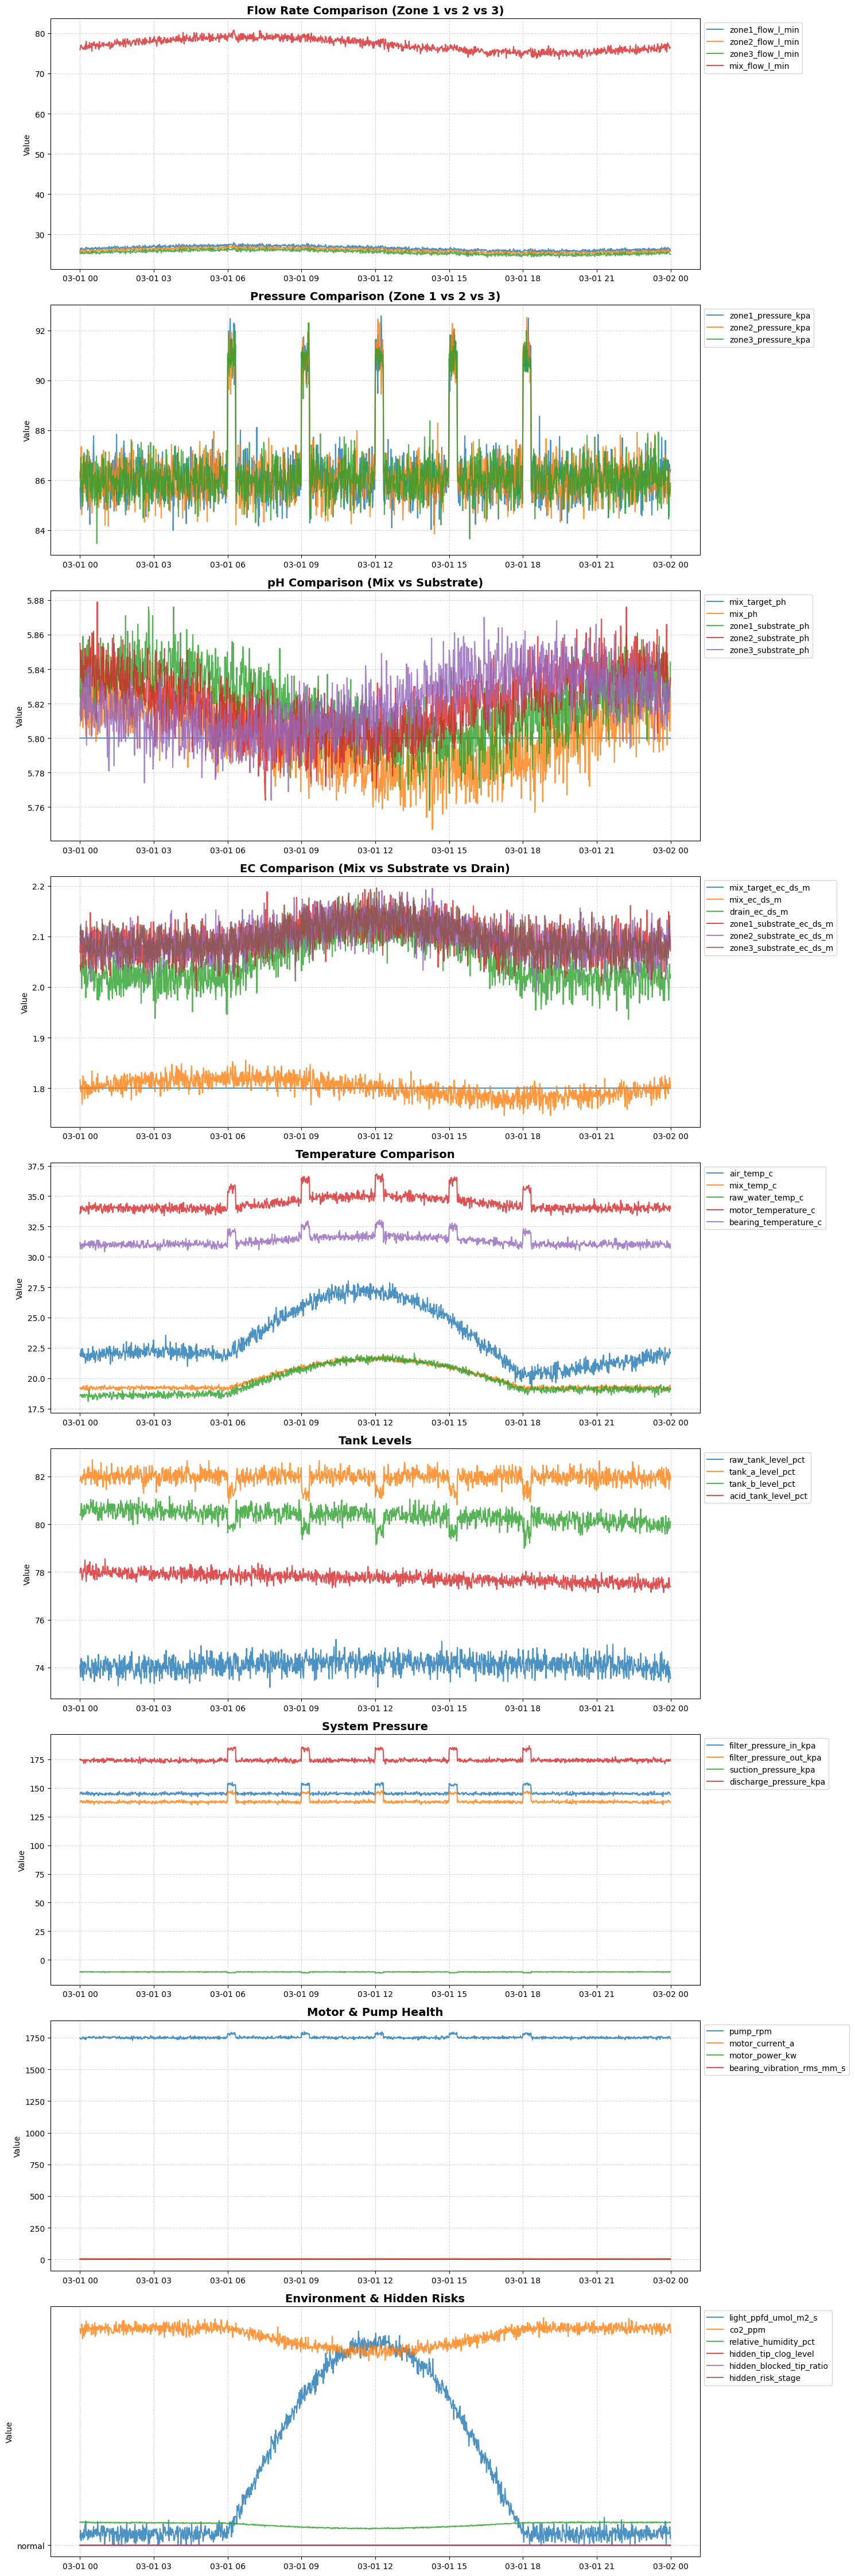

In [18]:
# 시각화 설정
n_groups = len(compare_groups)
fig, axes = plt.subplots(n_groups, 1, figsize=(15, 5 * n_groups))


minute_per_day = 60*24

# 데이터가 너무 많으면 그래프가 무거우니 하루 정도만 샘플링해서 보기
plot_df = df_raw.iloc[:minute_per_day] 
#plot_df = df_raw

for i, (title, cols) in enumerate(compare_groups.items()):
    ax = axes[i]
    
    # 존재하는 컬럼만 그리기
    valid_cols = [c for c in cols if c in plot_df.columns]
    
    for col in valid_cols:
        ax.plot(plot_df.index, plot_df[col], label=col, alpha=0.8, linewidth=1.5)
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1)) # 범례를 그래프 밖에 표시
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_ylabel("Value")

plt.tight_layout()
plt.show()

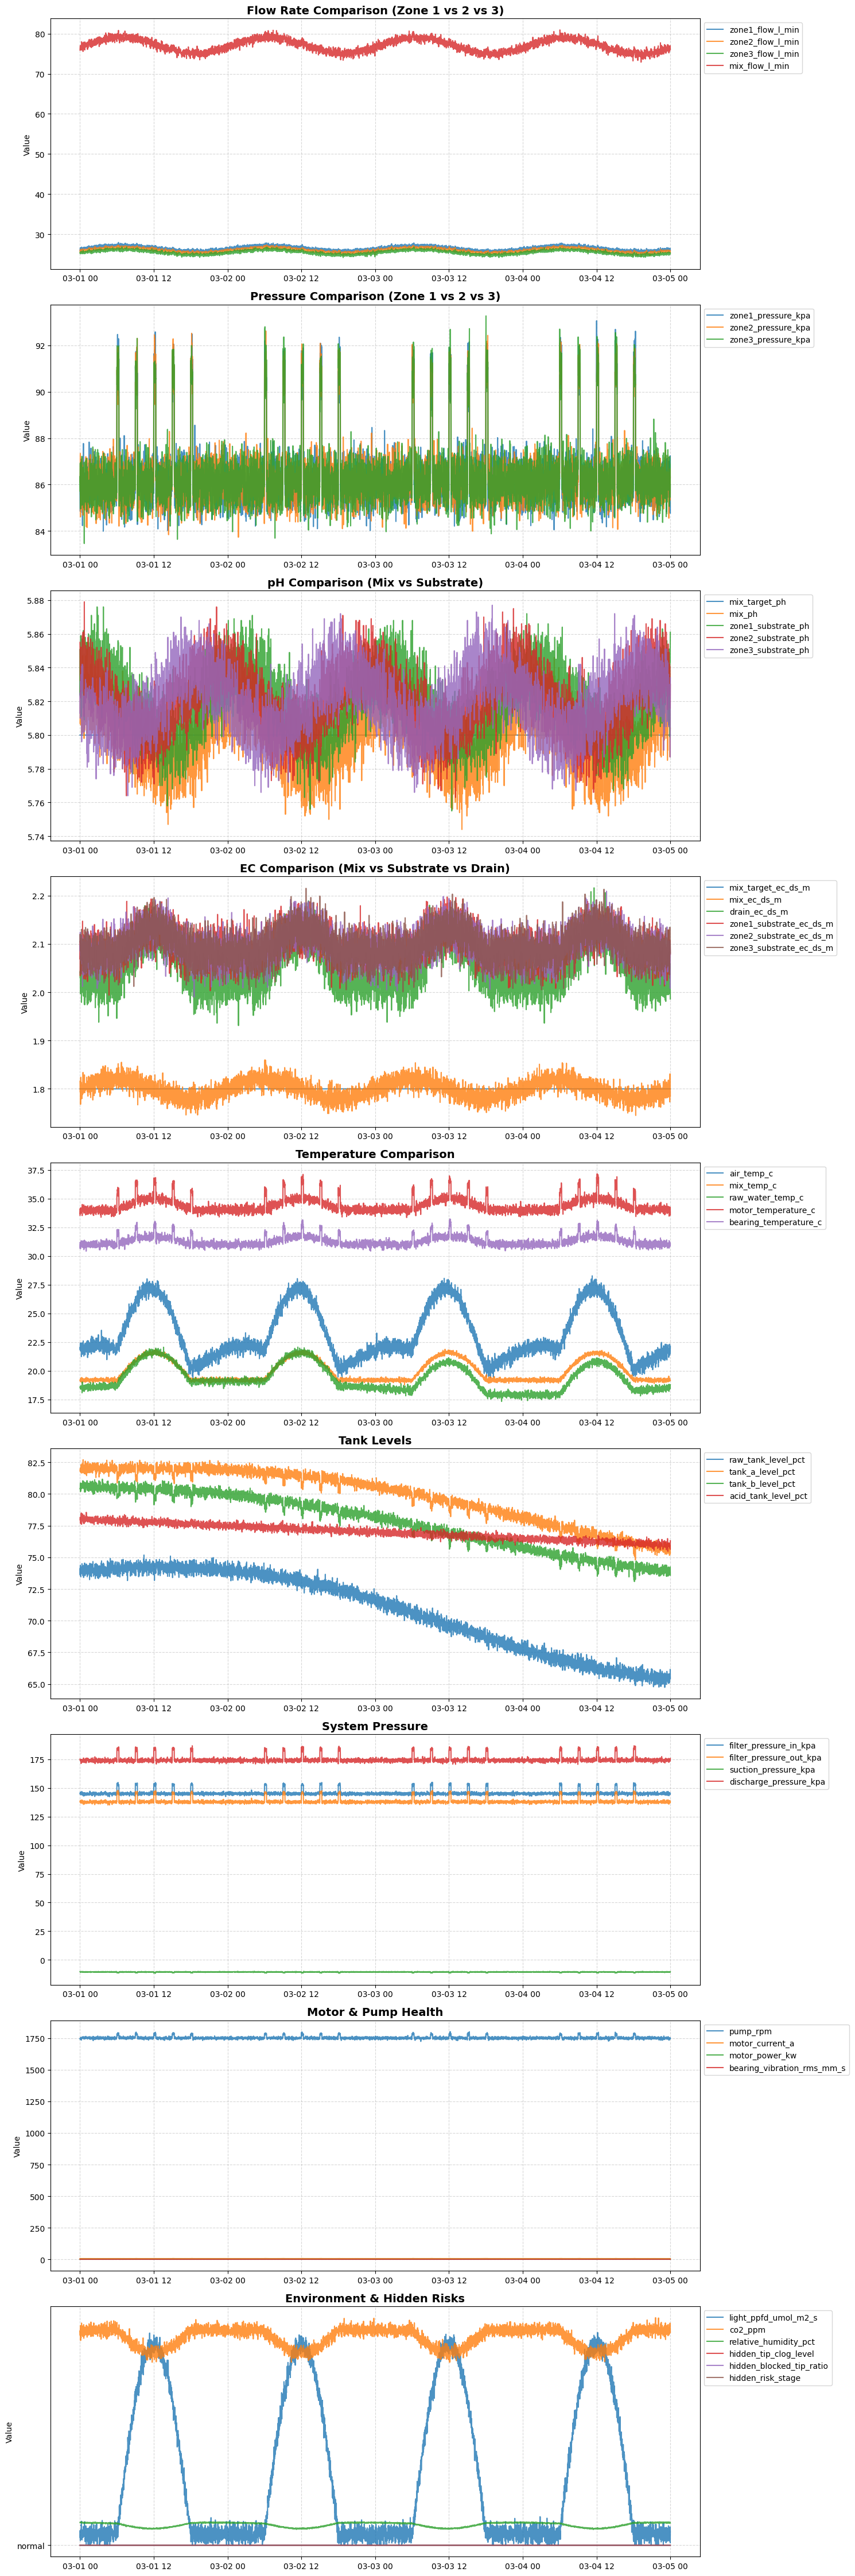

In [19]:
# 시각화 설정
n_groups = len(compare_groups)
fig, axes = plt.subplots(n_groups, 1, figsize=(15, 5 * n_groups))

minute_per_day = 60*24*2

# 이틀 정도만 샘플링해서 보기
plot_df = df_raw.iloc[:minute_per_day*2] 
#plot_df = df_raw

for i, (title, cols) in enumerate(compare_groups.items()):
    ax = axes[i]
    
    # 존재하는 컬럼만 그리기
    valid_cols = [c for c in cols if c in plot_df.columns]
    
    for col in valid_cols:
        ax.plot(plot_df.index, plot_df[col], label=col, alpha=0.8, linewidth=1.5)
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1)) # 범례를 그래프 밖에 표시
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_ylabel("Value")

plt.tight_layout()
plt.show()

# 파생변수 생성 및 컬럼 삭제


In [20]:
df_copy = df_raw.copy()

In [21]:
df_copy.columns

Index(['light_ppfd_umol_m2_s', 'air_temp_c', 'relative_humidity_pct',
       'co2_ppm', 'raw_tank_level_pct', 'raw_water_temp_c', 'pump_rpm',
       'flow_baseline_l_min', 'flow_rate_l_min', 'suction_pressure_kpa',
       'discharge_pressure_kpa', 'motor_current_a', 'motor_power_kw',
       'bearing_vibration_rms_mm_s', 'motor_temperature_c',
       'bearing_temperature_c', 'filter_pressure_in_kpa',
       'filter_pressure_out_kpa', 'turbidity_ntu', 'mix_target_ec_ds_m',
       'mix_ec_ds_m', 'mix_target_ph', 'mix_ph', 'mix_temp_c',
       'mix_flow_l_min', 'dosing_acid_ml_min', 'drain_ec_ds_m',
       'tank_a_level_pct', 'tank_b_level_pct', 'acid_tank_level_pct',
       'zone1_flow_l_min', 'zone1_pressure_kpa',
       'zone1_substrate_moisture_pct', 'zone1_substrate_ec_ds_m',
       'zone1_substrate_ph', 'zone2_flow_l_min', 'zone2_pressure_kpa',
       'zone2_substrate_moisture_pct', 'zone2_substrate_ec_ds_m',
       'zone2_substrate_ph', 'zone3_flow_l_min', 'zone3_pressure_kpa',
    

In [22]:
remove_cols = [
"flow_baseline_l_min",
"cleaning_event_flag",
"hidden_tip_clog_level",
"hidden_blocked_tip_ratio",
"hidden_risk_stage"
]

In [23]:
df_copy = df_copy.drop(columns=remove_cols)

---
---



In [24]:
# 💻 스마트팜 예지보전 데이터 전처리 및 피처 엔지니어링 파이프라인

import pandas as pd
import numpy as np

eps = 1e-6 # 0 나누기 방지

# ==============================================================================
# 1. 유효 데이터 필터링 (낮 시간 & 관수 가동 중)
# ==============================================================================
def filter_active_periods(df):
    """
    조명이 켜져 있는 주간 시간대이면서, 실제로 펌프나 구역 밸브가 작동한 시점만 필터링합니다.
    야간이나, 낮이더라도 물을 주지 않는 대기 시간은 분석에서 제외하여 노이즈를 줄입니다.
    """
    # 조건: 조명이 켜져있고(lights_on == 1) AND (펌프가 돌거나 OR 1~3구역 밸브 중 하나라도 열림)
    active_condition = (df['lights_on'] == 1) & (
        (df['pump_on'] == 1) | 
        (df['zone1_valve_on'] == 1) | 
        (df['zone2_valve_on'] == 1) | 
        (df['zone3_valve_on'] == 1)
    )
    return df[active_condition].copy()



# ==============================================================================
# 2. 모델 학습용 파생변수 생성 (Raw 데이터 기반)
# ==============================================================================

def create_modeling_features(df):
    """
    주니어 님의 도메인 메모(List)를 100% 반영한 고도화된 파생변수 생성 함수입니다.
    이 함수는 10분 단위 집계(Aggregation)를 하기 전, 1분 단위 Raw Data 상태에서 실행해야 가장 정확합니다.
    """
    df_feat = df_copy
    eps = 1e-6
    
    # 시간 단위 변화율을 구하기 위해 인덱스의 시간차(초 단위) 계산 (연속된 데이터라 가정)
    # 인덱스가 datetime이어야 작동합니다.
    if pd.api.types.is_datetime64_any_dtype(df_feat.index):
        dt_seconds = df_feat.index.to_series().diff().dt.total_seconds().fillna(60)
    else:
        dt_seconds = 60 # 기본값 1분(60초)

    # =====================================================================
    # 1. 압력 & 유량 & 전력 기본 조합 지표 (해석용과 학습용 공통 사용 가능)
    # =====================================================================
    # 차압 (Differential Pressure)
    # 펌프가 실제로 물을 끌어올려 밀어낸 순수 압력 에너지입니다.
    # [Rule] 차압이 급감하면 펌프 임펠러 손상이나 공기 유입(캐비테이션)을 의심해야 합니다.
    df_feat['differential_pressure_kpa'] = df_feat['discharge_pressure_kpa'] - df_feat['suction_pressure_kpa']

    # 유량 감소율 (Flow Drop Rate)
    # 정상적인 기준치 대비 현재 유량이 얼마나 줄었는지 백분율로 나타냅니다.
    # [Rule] 유량이 급감(-)하면 공압, 실린더, 배관 막힘 등 물리적 저항이 발생했음을 의미합니다.
    # baseline은 최근 1시간(60분) 이동평균으로 설정
    df_feat['flow_baseline_l_min'] = df_feat['flow_rate_l_min'].rolling(window=60, min_periods=1).mean().shift(1)
    df_feat['flow_drop_rate'] = (df_feat['flow_baseline_l_min'] - df_feat['flow_rate_l_min']) / (df_feat['flow_baseline_l_min'] + eps)

    # =====================================================================
    # [추가] 1-2. 펌프 수력학 및 시스템 효율 지표
    # =====================================================================
    # 필터 전후 압력 차 (Filter Delta P)
    df_feat['filter_delta_p_kpa'] = df_feat['filter_pressure_in_kpa'] - df_feat['filter_pressure_out_kpa']

    # 유체에 전달된 유효 동력 (Hydraulic Power, kW)
    # 수식: (유량(L/min) * 차압(kPa)) / 60,000
    df_feat['hydraulic_power_kw'] = (df_feat['flow_rate_l_min'] * df_feat['differential_pressure_kpa']) / 60000

    # 모터 입력 대비 출력 효율 (Wire-to-Water Efficiency)
    # 수식: 유효 동력 / 전기 입력 전력
    df_feat['wire_to_water_efficiency'] = df_feat['hydraulic_power_kw'] / (df_feat['motor_power_kw'] + eps)


    # =====================================================================
    # 2. 온도 & 진동 동특성 지표
    # =====================================================================
    # 초당 모터 온도 변화율 (Temperature Slope)
    # 1초당 온도가 몇 도(℃) 상승/하강하는지 나타냅니다.
    # [Rule] 모터나 베어링이 갈리거나 장기적으로 막혀 부하가 심해지면, 온도가 서서히 올라가며 이 값이 지속적인 양수(+)를 띕니다.
    df_feat['temp_slope_c_per_s'] = df_feat['motor_temperature_c'].diff() / dt_seconds

    # RPM 안정성 지수 (RPM Stability Index)
    # 목표 RPM(또는 평균 RPM) 대비 현재 RPM의 떨림 정도입니다. (여기서는 직전 10분 평균 대비 차이로 계산)
    # [Rule] 펌프에 공기가 차거나 난류가 발생하면 RPM이 목표값을 유지하지 못하고 요동칩니다.
    rpm_mean = df_feat['pump_rpm'].rolling(window=10, min_periods=1).mean()
    df_feat['rpm_stability_index'] = np.abs(df_feat['pump_rpm'] - rpm_mean) / (rpm_mean + eps)

    # =====================================================================
    # 3. 양액/수질 및 환경 고도화 지표
    # =====================================================================
    # 제어기 목표 추종 오차 (PID Error EC / pH)
    # 기계가 목표로 한 EC/pH 값과 실제 섞여서 나온 값의 차이입니다.
    # [Rule] 오차가 지속적으로 크면 조제기 밸브 노후화, 산/비료 원액 고갈, 혼합 모터 고장을 의미합니다.
    df_feat['pid_error_ec'] = df_feat['mix_ec_ds_m'] - df_feat['mix_target_ec_ds_m']
    df_feat['pid_error_ph'] = df_feat['mix_ph'] - df_feat['mix_target_ph']

    # pH 불안정성 (침전 발생 임계점 6.5 초과 여부)
    # 배관 막힘의 주원인인 '칼슘/인산 침전'이 발생하는 pH 6.5 이상의 위험 상태를 플래그(1/0)로 만듭니다.
    # [Rule] 이 플래그가 켜진 상태가 오래 유지되면, 곧 배관이 막힌다는 강력한 예지 시그널입니다.
    df_feat['ph_instability_flag'] = (df_feat['mix_ph'] > 6.5).astype(int)

    # 누적 염분 부하량 추정치 (Cumulative Salt Load)
    # 배지에서 빠져나오는 배액 EC와 들어가는 공급 EC의 차이를 의미합니다.
    # [Rule] 배액 EC가 공급 EC보다 지속적으로 높으면 염류가 축적(막힘 유발)되고, 낮으면 식물이 영양결핍 상태입니다.
    df_feat['salt_accumulation_delta'] = df_feat['drain_ec_ds_m'] - df_feat['mix_ec_ds_m']

    # 광합성 유효 광량자속 밀도 누적 프록시 (DLI Proxy)
    # 순간 광량(PPFD)을 누적하여 하루 동안 식물이 받은 총 빛의 양(DLI)을 추정합니다.
    # [Rule] 빛을 많이 받을수록 식물은 물을 많이 먹습니다. 빛은 많은데 배액률이 늘어난다면 뿌리가 죽었거나 점적 핀이 빠진 것입니다.
    # DLI 공식: PPFD * 시간(초) / 1,000,000 = mol/m²/day
    df_feat['daily_light_integral_proxy'] = (df_feat['light_ppfd_umol_m2_s'] * dt_seconds) / 1_000_000

    # 하루 누적 광량 (Daily Light Integral, mol/m²/d)
    # proxy 값을 날짜(Date) 단위로 그룹화하여 누적합(cumsum)을 구합니다.
    df_feat['daily_light_integral_mol_m2_d'] = df_feat.groupby(df_feat.index.date)['daily_light_integral_proxy'].cumsum()

    # =====================================================================
    # [추가] 3-2. 식물 환경 스트레스 지표 (VPD) 복구 완료
    # =====================================================================
    T = df_feat['air_temp_c']
    RH = df_feat['relative_humidity_pct']
    # Tetens formula 적용: 권장 VPD 범위는 0.5 ~ 1.2 kPa [cite: 30]
    e_s = 0.61078 * np.exp((17.27 * T) / (T + 237.3)) 
    df_feat['calculated_vpd_kpa'] = e_s - (e_s * (RH / 100))

    # =====================================================================
    # 4. 탱크 및 자원 소진 예측 지표
    # =====================================================================
    # 탱크 수위 변화율 (Tank Level Change Pct per Min)
    # 1분 동안 원수 탱크 수위가 몇 % 줄어드는지 소모 속도를 계산합니다.
    # [Rule] 관수를 안 하는데 수위가 줄어들면 탱크 누수이며, 펌프가 도는데 수위가 안 줄면 센서 고장이나 원수 밸브 막힘입니다.
    df_feat['raw_tank_level_change_pct_per_min'] = df_feat['raw_tank_level_pct'].diff() / (dt_seconds / 60)
    
    # A/B/산 탱크 고갈 예상 시간 (Estimated Hours to Empty)
    # 현재 소비 속도를 바탕으로 비료통이 언제 텅 빌지 예측합니다. (음수 변화량 활용)
    # [Rule] 값이 급격히 0에 수렴하면 농장주에게 비료를 타라고 알람을 주어야 합니다.
    for tank in ['tank_a', 'tank_b', 'acid_tank']:
        # 최근 10분간의 평균 감소 속도 (%/min)
        consumption_rate = -df_feat[f'{tank}_level_pct'].diff().rolling(window=10, min_periods=1).mean()
        consumption_rate = consumption_rate.clip(lower=eps) # 0 이하(채우고 있는 중) 방지
        # 남은 시간(분) = 남은 잔량 / 분당 소모량 -> 시간(Hour)으로 변환
        df_feat[f'{tank}_est_hours_to_empty'] = (df_feat[f'{tank}_level_pct'] / consumption_rate) / 60

    # =====================================================================
    # 5. 구역(Zone) 복합 제어 지표
    # =====================================================================
    # 활성 구역 개수 (Active Zone Count)
    # 현재 동시에 물이 들어가고 있는 베드의 개수입니다.
    # [Rule] 1구역만 열릴 때와 3구역이 동시에 열릴 때 펌프의 토출 압력과 유량 기준치가 달라야 합니다. (다중공선성을 막고 모델에 Context 제공)
    #df_feat['active_zone_count'] = df_feat['zone1_valve_on'] + df_feat['zone2_valve_on'] + df_feat['zone3_valve_on']

    # 공급 밸런스 지수 (Supply Balance Index)
    # 펌프가 밀어낸 총 유량 대비 각 구역으로 들어간 유량의 합의 비율입니다.
    # [Rule] 메인 펌프 유량은 100인데 구역 유량 합이 70이라면, 중간 배관 어딘가에서 누수가 발생한 것입니다.
    zone_flow_sum = df_feat['zone1_flow_l_min'] + df_feat['zone2_flow_l_min'] + df_feat['zone3_flow_l_min']
    df_feat['supply_balance_index'] = zone_flow_sum / (df_feat['flow_rate_l_min'] + eps)

    # =====================================================================
    # [추가] 5-2. 구역별 수분 반응 지표
    # =====================================================================
    # 급액 후 수분 변화량 (Moisture Response)
    # 직전 1분 대비 현재 배지 수분이 얼마나 올랐는지(+) 계산합니다.
    for i in range(1, 4):
        df_feat[f'zone{i}_moisture_response_pct'] = df_feat[f'zone{i}_substrate_moisture_pct'].diff()
        # -------------------------------------------------------------
        # [추가] 5-2. 구역별 배관 저항 및 염류 축적량 지표
        # -------------------------------------------------------------
        # 배관 저항 = 압력 / 유량 (유량이 0일 때 무한대 방지를 위해 eps 더함)
        df_feat[f'zone{i}_resistance'] = df_feat[f'zone{i}_pressure_kpa'] / (df_feat[f'zone{i}_flow_l_min'] + eps)
        
        # 염류 축적량 = 배지 측정 EC - 공급 양액 EC
        df_feat[f'zone{i}_ec_accumulation'] = df_feat[f'zone{i}_substrate_ec_ds_m'] - df_feat['mix_ec_ds_m']

    return df_feat

# ==============================================================================
# 3. 데이터 시계열 윈도우 집계 (Tumbling vs Sliding)
# ==============================================================================
def aggregate_time_window(df, method='tumbling', window_size='10min', slide_step='1min'):
    """
    연속된 시계열 데이터를 머신러닝 모델이 소화하기 좋게 윈도우 단위로 묶어줍니다.
    """
    # 연속형 수치 데이터만 평균(mean)으로 집계한다고 가정
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    
    if method == 'tumbling':
        # 1. 텀블링 윈도우 (Non-overlapping)
        # 1시간을 10분씩 겹치지 않게 딱 6개로 쪼갭니다. 데이터 크기가 작아지고 학습이 빠릅니다.
        df_agg = df[numeric_cols].resample(window_size).mean()
        
    elif method == 'sliding':
        # 2. 슬라이딩 윈도우 (Overlapping)
        # 10분 크기의 창을 1분(slide_step)씩 옆으로 밀면서 집계합니다. 
        # 데이터 포인트가 많아져 AutoEncoder가 더 미세한 패턴 변화를 학습하기 좋습니다. (현업 추천)
        df_agg = df[numeric_cols].rolling(window=window_size).mean()
        # rolling은 기본적으로 데이터 주파수를 바꾸지 않으므로, step 주기로 샘플링
        df_agg = df_agg.resample(slide_step).first() 
        
    # 집계 후 결측치 발생 구간(가동 중지 구간 등) 제거
    return df_agg.dropna()

In [25]:

# ==============================================================================
# 4. 결과 해석용 파생변수 생성 (강사님 지표 분리)
# ==============================================================================

# extract_interpretation_features 함수는 텀블링 윈도우든 슬라이딩 윈도우든 전혀 수정할 필요 없이 그대로 사용하면 됨.

def extract_interpretation_features(df_agg):
    """
    AutoEncoder의 입력으로 쓰지 않고, 
    나중에 '왜 고장 징후(Anomaly)로 판별했는가?'를 해석할 때 모니터링용으로 쓸 강사님의 피처들입니다.
    윈도우 집계가 끝난 데이터(df_agg) 위에서 계산합니다.
    """
    eps = 1e-6
    df_interpret = pd.DataFrame(index=df_agg.index)
    
    # ---------------------------------------------------------
    # 1. 유량 대비 압력 비율 (Pressure Flow Ratio)
    # [Rule] 펌프 효율 저하 지표. 같은 압력을 가했는데 유량이 줄었다면 관로 막힘 의심, 반대면 누수 의심.
    df_interpret["pressure_flow_ratio"] = df_agg['discharge_pressure_kpa'] / (df_agg['flow_rate_l_min'] + eps) 

    # ---------------------------------------------------------
    # 2. 차압 대비 유량 (Differential Pressure per Flow)
    # [Rule] 토출과 흡입 압력의 차이(순수 펌프 에너지) 대비 유량. 값이 상승하면 에너지만 쓰고 물은 못 밀어내는 비정상 부하 상태입니다.
    df_interpret["dp_per_flow"] = (df_agg['discharge_pressure_kpa'] - df_agg['suction_pressure_kpa']) / (df_agg['flow_rate_l_min'] + eps)

    # ---------------------------------------------------------
    # 3. 압력 대비 전력 효율 (Pressure per Power)
    # [Rule] 압력을 유지하기 위해 전력을 과하게 쓰고 있다면 모터의 베어링 마모 등 기계적 부하가 걸린 상태입니다.
    df_interpret["pressure_per_power"]  = df_agg['discharge_pressure_kpa'] / (df_agg['motor_power_kw'] + eps)
    
    # ---------------------------------------------------------
    # 4. 유량 대비 전력 효율 (Flow per Power)
    # [Rule] 동일한 전력을 소모하는데 유량이 줄어들면, 모터나 펌프 내부의 기계적 마찰이 심해졌음을 의미합니다.
    df_interpret["flow_per_power"] = df_agg['flow_rate_l_min'] / (df_agg['motor_power_kw'] + eps)

    # ---------------------------------------------------------
    # 5. 유량 감소율 (Flow Drop Rate)
    # [Rule] 정상적인 기준치 대비 현재 얼마나 흐름이 약해졌는지 백분율로 나타냅니다.
    # 주의: 이 값은 1분 단위 원천 데이터에서 계산되어 df_agg로 넘어온 상태이므로 재계산하지 않고 가져옵니다.
    if 'flow_drop_rate' in df_agg.columns:
        df_interpret["flow_drop_rate"] = df_agg['flow_drop_rate']
    else:
        # 혹시 이전 단계에서 누락되었을 경우를 대비한 예외 처리 (10분 평균값 기반으로 임시 계산)
        flow_baseline_10m = df_agg['flow_rate_l_min'].rolling(window=6, min_periods=1).mean().shift(1)
        df_interpret["flow_drop_rate"] = (flow_baseline_10m - df_agg['flow_rate_l_min']) / (flow_baseline_10m + eps)

    return df_interpret

In [26]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import shap

# =====================================================================
# 1. 단일 타겟에 대한 모델 학습 및 SHAP 중요도 추출 함수
# =====================================================================
def get_shap_importance(X, y, target_name, n_estimators=100, random_state=42):
    print(f"[{target_name}] 모델 학습 및 SHAP 계산 중... (전체 데이터: {len(X)}개)")
    
    # 1. 모델 학습 (학습은 빠르므로 전체 데이터 43,199개 모두 사용)
    # 트리가 너무 깊어지는 것을 방지하기 위해 max_depth를 15 정도로 제한하면 훨씬 빠르고 과적합도 막아줍니다.
    model = RandomForestRegressor(n_estimators=n_estimators, max_depth=15, random_state=random_state, n_jobs=-1)
    model.fit(X, y)
    
    # 2. SHAP 값 계산 (★핵심 최적화: SHAP 계산용 데이터는 3000개만 무작위 샘플링)
    sample_size = min(3000, len(X))
    X_sample = X.sample(n=sample_size, random_state=random_state)
    
    print(f"  -> SHAP 연산 가속을 위해 {sample_size}개 샘플링 완료. 계산 시작...")
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample)
    
    # 3. 피처별 SHAP 중요도 계산
    shap_sum = np.abs(shap_values).mean(axis=0)
    importance_df = pd.DataFrame({
        'Feature': X.columns,
        'SHAP_Importance': shap_sum
    }).sort_values('SHAP_Importance', ascending=False).reset_index(drop=True)
    
    return explainer, shap_values, importance_df


def get_shap_importance_kmeans(X, y, target_name, n_estimators=100, random_state=42):

    """
    트리 기반 모델(Random Forest, XGBoost)은 데이터의 크기나 비율보다는 **'순서(Rank)'**를 기준으로 분기를 나누기 때문에 스케일링이 전혀 필요 없습니다.
    하지만 K-Means는 '유클리디안 거리(Euclidean Distance)'를 계산하기 때문에 스케일링을 안 하면 대참사가 일어납니다. 
    예를 들어 압력 센서는 1000 단위로 움직이고, 밸브 상태는 0~1로 움직인다면 K-Means는 압력 센서만 보고 군집을 엉터리로 나눠버립니다.
    """

    print(f"[{target_name}] 모델 학습 및 K-Means SHAP 계산 중... (전체 데이터: {len(X)}개)")
    
    # 1. 모델 학습 (RF는 스케일링이 필요 없으므로 원본 데이터 X를 그대로 사용)
    model = RandomForestRegressor(n_estimators=n_estimators, max_depth=15, random_state=random_state, n_jobs=-1)
    model.fit(X, y)
    
    # =====================================================================
    # 🌟 [스케일링 및 K-Means 압축 로직]
    # =====================================================================
    print(f"  -> K-Means 클러스터링을 위한 데이터 스케일링 및 대표 패턴 압축 중...")
    
    # [추가됨] K-Means를 위한 임시 스케일링 (평균 0, 분산 1)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    n_clusters = min(300, len(X)) 
    
    # K-Means 모델은 '스케일링된 데이터'로 학습하여 공평하게 거리를 잼
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init='auto')
    kmeans.fit(X_scaled)
    
    # [추가됨] 💥 핵심: SHAP 계산 시 원래의 센서 단위(압력, 유량 등)로 해석하기 위해 
    # 스케일링된 군집 중심점들을 다시 원래 스케일로 역변환(inverse_transform) 해줍니다.
    centers_original_scale = scaler.inverse_transform(kmeans.cluster_centers_)
    
    # 역변환된 중심점을 DataFrame으로 만듦
    X_background = pd.DataFrame(centers_original_scale, columns=X.columns)
    
    print(f"  -> 대표 패턴 {n_clusters}개 추출 및 역변환 완료. SHAP 계산 시작...")
    # =====================================================================
    
    # 3. SHAP 값 계산 (원래 스케일로 돌아온 X_background를 넣습니다)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_background, approximate=True)
    
    # 4. 피처별 SHAP 중요도 계산
    shap_sum = np.abs(shap_values).mean(axis=0)
    importance_df = pd.DataFrame({
        'Feature': X.columns,
        'SHAP_Importance': shap_sum
    }).sort_values('SHAP_Importance', ascending=False).reset_index(drop=True)
    
    return explainer, shap_values, X_background, importance_df


# =====================================================================
# 2. Multi-Target SHAP Ensemble 메인 함수
# =====================================================================
def run_shap_ensemble(df, target_dict, top_ratio=0.2):
    """
    여러 타겟에 대해 SHAP 분석을 수행하고, 상위 피처들의 교집합/합집합을 도출합니다.
    
    :param df: 전체 데이터프레임 (파생변수 포함, 결측치 처리 완료 상태)
    :param target_dict: 타겟 이름과 해당 타겟의 '누수(Leakage) 방지용 제외 컬럼'을 매핑한 딕셔너리
    :param top_ratio: 각 타겟별로 상위 몇 %의 피처를 선정할 것인지 (기본 20%)
    :return: 최종 선정된 피처 리스트, 각 타겟별 중요도 DF 딕셔너리
    """
    all_features = df.columns.tolist()
    
    importance_results = {}
    shap_values_dict = {}
    x_background_dict = {}
    
    top_features_per_target = {}
    
    # 각 타겟별로 순회하며 SHAP 추출
    for target, leak_cols in target_dict.items():
        # X, y 분리 (타겟 본인과, 타겟을 계산하는 데 쓰인 부모 컬럼들 제외)
        cols_to_drop = [target] + leak_cols
        X = df.drop(columns=[col for col in cols_to_drop if col in df.columns])
        y = df[target]
        
        # 결측치가 있으면 RF가 안 돌아가므로 임시로 평균 채우기 (이미 전처리 하셨다면 생략 가능)
        X = X.fillna(X.mean())
        y = y.fillna(y.mean())
        
        # SHAP 중요도 계산
        _, shap_vals, x_bg, imp_df = get_shap_importance_kmeans(X, y, target)
        
        # 딕셔너리에 저장
        importance_results[target] = imp_df
        shap_values_dict[target] = shap_vals
        x_background_dict[target] = x_bg
        
        # 상위 N% 피처 추출
        top_n_count = max(1, int(len(X.columns) * top_ratio))
        top_features = imp_df.head(top_n_count)['Feature'].tolist()
        top_features_per_target[target] = set(top_features)
        
        print(f"  -> 상위 {top_ratio*100}% ({top_n_count}개) 피처 선정 완료\n")

    # 3. 앙상블 논리 적용 (교집합 및 합집합)
    list_of_sets = list(top_features_per_target.values())
    
    # 교집합: 3개 고장 모드 모두에서 공통으로 중요한 핵심 피처 (가장 강력함)
    intersection_features = set.intersection(*list_of_sets)
    
    # 합집합: 하나라도 중요하다고 뜬 피처 (풀(Pool)을 넓게 가져갈 때)
    union_features = set.union(*list_of_sets)
    
    # 최소 2개 이상의 타겟에서 중요하다고 꼽힌 피처 (가장 추천하는 현실적 타협안)
    from collections import Counter
    all_selected_features = [feat for feature_set in list_of_sets for feat in feature_set]
    feature_counts = Counter(all_selected_features)
    robust_features = [feat for feat, count in feature_counts.items() if count >= 2]
    
    print("="*50)
    print("🏆 Multi-Target SHAP Ensemble 결과 요약")
    print("="*50)
    print(f"1. 교집합 (모두에서 중요): {len(intersection_features)}개")
    print(f"2. 투표(Voting, 2개 이상 타겟에서 중요): {len(robust_features)}개  <-- [AutoEncoder 추천]")
    print(f"3. 합집합 (전체 풀): {len(union_features)}개")

    # 🌟 [수정됨] 3가지 앙상블 리스트를 딕셔너리로 묶어서 반환합니다.
    ensemble_lists = {
        'intersection': list(intersection_features),
        'robust': robust_features,
        'union': list(union_features)
    }
    
    return ensemble_lists, importance_results, shap_values_dict, x_background_dict


# =====================================================================
# 3. 시각화 보조 함수 (특정 타겟의 SHAP Top 15 시각화)
# =====================================================================
def plot_shap_top_n(importance_df, target_name, top_n=15):
    plt.figure(figsize=(10, 6))
    data_to_plot = importance_df.head(top_n)
    sns.barplot(x='SHAP_Importance', y='Feature', data=data_to_plot, palette='viridis')
    plt.title(f'[{target_name}] SHAP 중요도 Top {top_n}', fontsize=15)
    plt.xlabel('Mean |SHAP value|', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    plt.tight_layout()
    plt.show()

/opt/homebrew/Caskroom/miniconda/base/envs/analyzer/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [27]:
# ==============================================================================
# [Pipeline Step 1] 파생변수 생성 및 윈도우 집계
# ==============================================================================
def step1_prepare_window_data(df_raw, window_method='sliding'):
    print(f"⏳ [Step 1] 파생변수 생성 및 {window_method.upper()} 윈도우 집계 시작...")
    
    # 1. 로우 데이터에서 물리적 파생변수 생성 (공통)
    df_features = create_modeling_features(df_raw)
    
    # 2. 윈도우 집계 (인자에 따라 다르게 동작)
    if window_method == 'sliding':
        df_agg = aggregate_time_window(df_features, method='sliding', window_size='10min', slide_step='1min')
    elif window_method == 'tumbling':
        df_agg = aggregate_time_window(df_features, method='tumbling', window_size='10min') 
    else:
        raise ValueError("window_method는 'sliding' 또는 'tumbling' 이어야 합니다.")
        
    # 3. [해석용 데이터] 모델 피처 삭제 전, 원본 윈도우 데이터에서 미리 분리
    df_interpret = extract_interpretation_features(df_agg)
    
    print(f"  -> 집계 완료! (집계 데이터: {df_agg.shape}, 해석용 데이터: {df_interpret.shape})")
    return df_agg, df_interpret

# ==============================================================================
# [Pipeline Step 2] 데이터 정제 및 다중공선성 제거
# ==============================================================================
def step2_clean_and_drop_collinear(df_agg):
    print("\n🧹 [Step 2] 데이터 정제 및 다중공선성 변수 제거 시작...")
    df_final = df_agg.copy()

    # 1. 무한대(Inf) 및 결측치(NaN) 처리
    df_final = df_final.replace([np.inf, -np.inf], np.nan)
    df_final = df_final.fillna(df_final.mean())

    # 2. 다중공선성 및 풍선효과 결과 변수들 수동 제거 리스트
    collinear_drop_list = [
        'tank_b_level_pct', 'acid_tank_level_pct', 
        'tank_a_est_hours_to_empty', 'tank_b_est_hours_to_empty', 'acid_tank_est_hours_to_empty',
        'zone2_flow_l_min', 'zone3_flow_l_min', 
        'zone2_pressure_kpa', 'zone3_pressure_kpa',
        'zone2_substrate_moisture_pct', 'zone3_substrate_moisture_pct',
        'zone2_substrate_ec_ds_m', 'zone3_substrate_ec_ds_m',
        'zone2_resistance', 'zone3_resistance',
        'relative_humidity_pct', 'mix_temp_c', 'raw_water_temp_c',
        'mix_flow_l_min', 'filter_pressure_out_kpa', 'hidden_tip_clog_level'
    ]

    # 3. 변수 걷어내기
    df_clean = df_final.drop(columns=[col for col in collinear_drop_list if col in df_final.columns])
    print(f"  -> 중복/노이즈 변수 {len(collinear_drop_list)}개 제거 완료! (남은 피처 수: {len(df_clean.columns)})")
    
    return df_clean

# ==============================================================================
# [Pipeline Step 3 & 4] SHAP 앙상블 실행 및 최종 AE 데이터 확정
# ==============================================================================
def step3_4_select_features_and_finalize(df_clean, df_interpret, target_dict, top_ratio=0.25):
    print("\n🔍 [Step 3] 정제된 데이터로 SHAP 기반 피처 셀렉션을 시작합니다...")
    
    # 1. 앙상블 실행
    ensemble_lists, shap_results, shap_vals_dict, X_bg_dict = run_shap_ensemble(df_clean, target_dict, top_ratio=top_ratio)
    
    # 2. 결과 출력 (Phase 4 기능 통합)
    print("\n🎯 [Step 4] 선정된 핵심 피처 리스트 및 최종 오토인코더 데이터 확정")
    print("-" * 60)
    print(f"1. 교집합 피처 ({len(ensemble_lists['intersection'])}개 - 모든 고장에 관여):")
    print(ensemble_lists['intersection'])

    print(f"\n2. Robust 피처 ({len(ensemble_lists['robust'])}개 - 추천! 2개 이상 고장에 관여):")
    print(ensemble_lists['robust'])

    print(f"\n3. 합집합 피처 ({len(ensemble_lists['union'])}개 - 전체 후보군):")
    print(ensemble_lists['union'])
    print("-" * 60)

    # 3. 최종 학습용 데이터셋(X_train_ae) 구축
    X_train_ae = df_clean[ensemble_lists['robust']].copy()

    print(f"\n✅ 최종 데이터 준비 완료!")
    print(f"  - 오토인코더 학습용 데이터 (X_train_ae) 형태: {X_train_ae.shape}")
    print(f"  - 결과 해석/모니터링용 데이터 (df_interpret) 형태: {df_interpret.shape}")
    
    return X_train_ae, ensemble_lists, shap_results, shap_vals_dict, X_bg_dict


def run_feature_selection_experiment(df_raw, window_method, target_dict):
    print(f"\n" + "="*60)
    print(f"🚀 [EXPERIMENT] 시작: {window_method.upper()} WINDOW 방식")
    print("="*60)
    
    start_time = time.time()
    
    # -------------------------------------------------------------------------
    # 🧱 완벽하게 모듈화된 파이프라인 조립 (단 3단계!)
    # -------------------------------------------------------------------------
    
    # 1. 파생변수 생성 및 윈도우 집계 (내부에서 알아서 sliding/tumbling 구분)
    df_agg, df_interpret = step1_prepare_window_data(df_raw, window_method=window_method)
    
    # 2. 데이터 정제 및 다중공선성(노이즈) 제거
    df_clean = step2_clean_and_drop_collinear(df_agg)
    
    # 3. SHAP 앙상블 실행 및 최종 데이터셋 생성 (밖에서 받아온 target_dict 사용)
    X_train_ae, ensemble_lists, shap_results, shap_vals_dict, X_bg_dict = step3_4_select_features_and_finalize(
        df_clean, df_interpret, target_dict, top_ratio=0.25
    )
    
    robust_features = ensemble_lists['robust']
    end_time = time.time()
    
    print(f"\n✅ [{window_method.upper()}] 실험 완료!")
    
    return robust_features, X_train_ae, df_interpret, shap_results

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# ⚔️ [메인 실행 블록] Sliding vs Tumbling A/B 테스트 및 시각화
# ==============================================================================
# 1. 타겟 딕셔너리 세팅
target_dictionary = {
    'filter_delta_p_kpa': ['filter_pressure_in_kpa'], 
    'zone1_resistance': ['zone1_pressure_kpa', 'zone1_flow_l_min'],
    'wire_to_water_efficiency': ['motor_power_kw', 'differential_pressure_kpa', 'flow_rate_l_min', 'hydraulic_power_kw']
}

print("🏁 윈도우 집계 방식론(Sliding vs Tumbling) A/B 테스트를 시작합니다.")

# 2. Tumbling 방식 실행 (주의: 리턴값 4개로 받기!)
features_tumbling, X_train_tumbling, interpret_tumbling, shap_res_tumbling = run_feature_selection_experiment(
    df_raw=df_copy, 
    window_method='tumbling', 
    target_dict=target_dictionary
)

# 3. Sliding 방식 실행 (주의: 리턴값 4개로 받기!)
features_sliding, X_train_sliding, interpret_sliding, shap_res_sliding = run_feature_selection_experiment(
    df_raw=df_copy, 
    window_method='sliding', 
    target_dict=target_dictionary
)

# ==============================================================================
# 📊 [파트 1: 결과 비교 분석 리포트 - Text]
# ==============================================================================
print("\n\n" + "★"*60)
print("🏆 [텍스트 리포트] SLIDING vs TUMBLING 추출 피처 비교")
print("★"*60)

set_tumbling = set(features_tumbling)
set_sliding = set(features_sliding)

print(f"\n[1] 추출된 데이터 크기 (Data Size)")
print(f"  - Tumbling (거시적 트렌드): {X_train_tumbling.shape[0]} rows")
print(f"  - Sliding (미세 전조증상): {X_train_sliding.shape[0]} rows")

print(f"\n[2] 공통으로 뽑힌 절대 피처 (Intersection: {len(set_tumbling & set_sliding)}개)")
print("  :", list(set_tumbling & set_sliding))

print(f"\n[3] Sliding 윈도우에서만 포착된 피처 (Only in Sliding: {len(set_sliding - set_tumbling)}개)")
print("  :", list(set_sliding - set_tumbling))

print(f"\n[4] Tumbling 윈도우에서만 포착된 피처 (Only in Tumbling: {len(set_tumbling - set_sliding)}개)")
print("  :", list(set_tumbling - set_sliding))
print("★"*60)

🏁 윈도우 집계 방식론(Sliding vs Tumbling) A/B 테스트를 시작합니다.

🚀 [EXPERIMENT] 시작: TUMBLING WINDOW 방식
⏳ [Step 1] 파생변수 생성 및 TUMBLING 윈도우 집계 시작...
  -> 집계 완료! (집계 데이터: (4320, 73), 해석용 데이터: (4320, 5))

🧹 [Step 2] 데이터 정제 및 다중공선성 변수 제거 시작...
  -> 중복/노이즈 변수 21개 제거 완료! (남은 피처 수: 53)

🔍 [Step 3] 정제된 데이터로 SHAP 기반 피처 셀렉션을 시작합니다...
[filter_delta_p_kpa] 모델 학습 및 K-Means SHAP 계산 중... (전체 데이터: 4320개)
  -> K-Means 클러스터링을 위한 데이터 스케일링 및 대표 패턴 압축 중...
  -> 대표 패턴 300개 추출 및 역변환 완료. SHAP 계산 시작...
  -> 상위 25.0% (12개) 피처 선정 완료

[zone1_resistance] 모델 학습 및 K-Means SHAP 계산 중... (전체 데이터: 4320개)
  -> K-Means 클러스터링을 위한 데이터 스케일링 및 대표 패턴 압축 중...
  -> 대표 패턴 300개 추출 및 역변환 완료. SHAP 계산 시작...
  -> 상위 25.0% (12개) 피처 선정 완료

[wire_to_water_efficiency] 모델 학습 및 K-Means SHAP 계산 중... (전체 데이터: 4320개)
  -> K-Means 클러스터링을 위한 데이터 스케일링 및 대표 패턴 압축 중...
  -> 대표 패턴 300개 추출 및 역변환 완료. SHAP 계산 시작...
  -> 상위 25.0% (12개) 피처 선정 완료

🏆 Multi-Target SHAP Ensemble 결과 요약
1. 교집합 (모두에서 중요): 1개
2. 투표(Voting, 2개 이상 타겟에서 중요): 8개  <-- [AutoEncoder 추천]
3. 합집합 (전체 풀):


👀 [시각화 리포트] Tumbling(좌측/파란색) vs Sliding(우측/주황색) 비교


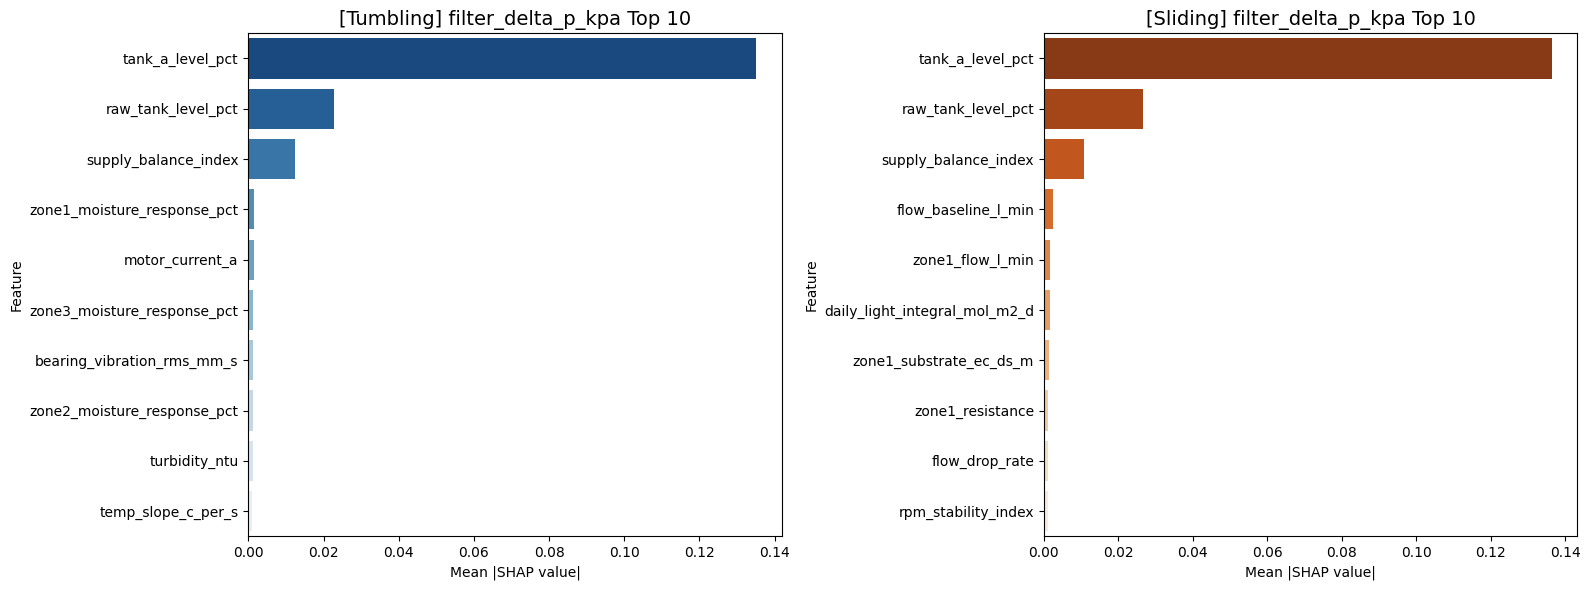

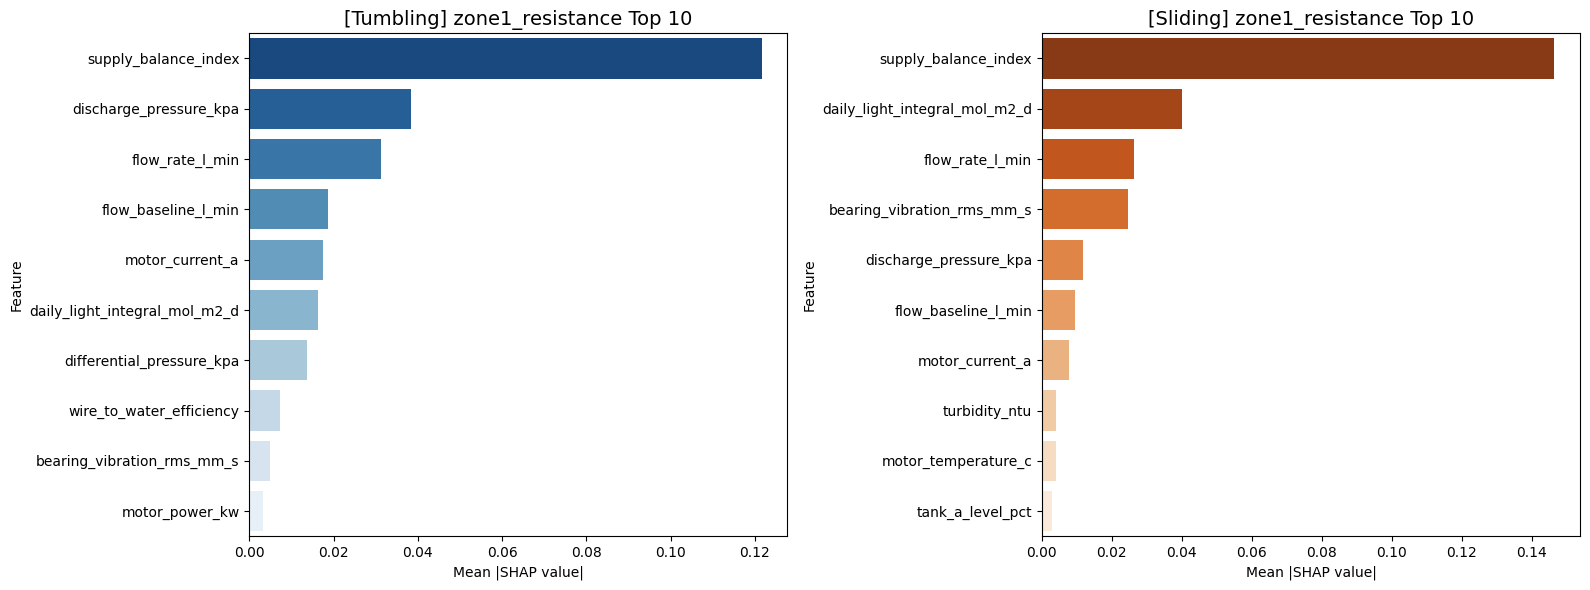

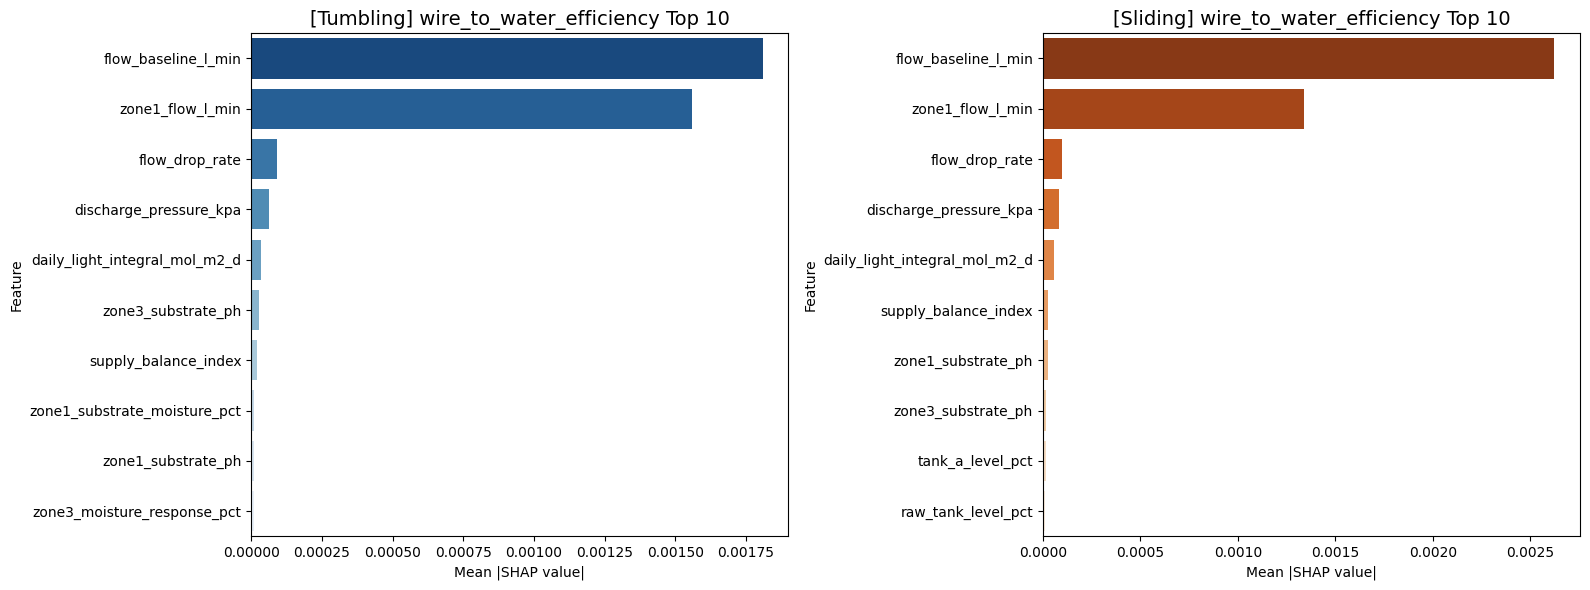

In [ ]:
# ==============================================================================
# 👀 [파트 2: 결과 비교 시각화 리포트 - Visual]
# ==============================================================================
# 나란히 비교하는 시각화 함수 정의 (Seaborn 경고 방지를 위해 hue 옵션 추가)
def compare_shap_visualizations(shap_res_tumb, shap_res_slid, target_name, top_n=10):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # 왼쪽: Tumbling 그래프
    data_tumb = shap_res_tumb[target_name].head(top_n)
    sns.barplot(x='SHAP_Importance', y='Feature', hue='Feature', data=data_tumb, ax=axes[0], palette='Blues_r', legend=False)
    axes[0].set_title(f'[Tumbling] {target_name} Top {top_n}', fontsize=14)
    axes[0].set_xlabel('Mean |SHAP value|')
    
    # 오른쪽: Sliding 그래프
    data_slid = shap_res_slid[target_name].head(top_n)
    sns.barplot(x='SHAP_Importance', y='Feature', hue='Feature', data=data_slid, ax=axes[1], palette='Oranges_r', legend=False)
    axes[1].set_title(f'[Sliding] {target_name} Top {top_n}', fontsize=14)
    axes[1].set_xlabel('Mean |SHAP value|')
    
    plt.tight_layout()
    plt.show() # Jupyter 환경에서 그래프를 즉시 렌더링

print("\n" + "="*60)
print("👀 [시각화 리포트] Tumbling(좌측/파란색) vs Sliding(우측/주황색) 비교")
print("="*60)

# 3가지 타겟에 대해 모두 듀얼 그래프 출력
for target in target_dictionary.keys():
    compare_shap_visualizations(shap_res_tumbling, shap_res_sliding, target, top_n=10)

Tumbling의 한계 (데이터 스무딩 현상): Tumbling은 10분 치 데이터를 모아서 하나의 평균값으로 퉁칩니다. 만약 10분 중 1분 동안만 배관이 살짝 막혀서 압력이 튀었다가 돌아왔다면, 평균을 내는 순간 그 '미세한 고장 전조(Anomaly)'는 정상 데이터에 묻혀서 사라져 버립니다.

Sliding의 강력함 (고해상도 추적): 반면 Sliding은 1분 단위로 계속 창을 밀어가며 겹쳐서 분석하므로, 미세한 변화를 놓치지 않습니다.

결정적 증거: Sliding에서만 **flow_drop_rate(유량 감소율)**과 motor_temperature_c(모터 온도), **zone1_resistance(구역 저항)**가 뽑힌 것을 보세요! 배관이 막히기 시작할 때 생기는 **'순간적인 유량 감소'**와 부하로 인한 **'모터 온도의 서서히 오르는 미세 변화'**는 예지보전에서 가장 중요한 골든타임 시그널입니다. Tumbling은 이 소중한 시그널을 평균의 함정으로 다 뭉개버린 겁니다.

In [30]:
pltfont.auto()

✅ 현재 폰트 적용됨: Arial Unicode MS


Multi-Target SHAP Ensemble

1. 세가지 Random Forest 만들기 
- 모델 A의 타겟: filter_delta_p_kpa (메인 배관 막힘 모델)

- 모델 B의 타겟: zone1_flow_resistance (구역 미세 막힘 모델)

- 모델 C의 타겟: wire_to_water_efficiency (펌프 기계 노후화 모델)

2. 모델에서 SHAP 중요도를 뽑습니다

3. 최종 피쳐 선정 논리
최종 피처 선정 논리: "이 세 가지 서로 다른 고장 모드(기계, 배관, 국소막힘)에서 공통적으로 SHAP 중요도 상위 20%에 랭크된 교집합(또는 합집합) 피처들을 최종 AutoEncoder의 Input으로 선정하였다. 이를 통해 특정 고장 모드에 편향되지 않은 강건한(Robust) 이상 탐지 모델을 구축할 수 있다."


데이터 누수(Data Leakage)**입니다.

🚨 주의: filter_delta_p_kpa를 타겟(y)으로 잡았을 때, 
입력 피처(X)에 filter_pressure_in_kpa나 filter_pressure_out_kpa가 남아있으면 안 됩니다. 
타겟이 저 두 값의 뺄셈으로 만들어졌기 때문에, RF 모델이 "아! 입구 압력에서 출구 압력을 빼면 정답이네?" 하고 수식만 100% 학습해 버립니다. 
진짜 우리가 알고 싶은 "모터 진동이나 유량이 막힘에 어떤 영향을 주는지"는 SHAP 밸류가 0으로 나와버리죠.

따라서 각 타겟마다 **'정답을 스포일러 하는 부모 변수들'**을 X에서 제외하고 학습하는 로직을 코드에 완벽하게 녹여내야 합니다.

💡 근거 1: 스마트팜 시계열 데이터의 '자기상관성(Autocorrelation)' 한계 극복

스마트팜 데이터는 1분 혹은 5분 단위로 쌓입니다. 낮 시간대의 온도 25℃, 습도 70% 상태는 아마 1시간 동안 거의 변하지 않고 수십 개의 데이터 포인트로 쌓여 있을 겁니다.
만약 43,000개에서 무작위로 3,000개를 뽑으면, 결국 똑같은 상태(낮 시간대 평시 상태)의 복제본 데이터만 잔뜩 뽑히게 됩니다. 이는 연산량만 낭비할 뿐, 모델이 다양한 고장 조건을 해석하는 데 전혀 도움이 되지 않습니다.

💡 근거 2: 데이터의 '다양성(Variance)' 보존

K-Means 클러스터링을 사용하여 300개의 중심점(Centroid)을 뽑는다는 것은, 전체 43,000개의 데이터를 300개의 **'대표 상태(Archetype)'**로 요약한다는 뜻입니다.

- 상태 A: 낮, 펌프 가동 중, 필터 압력 높음
- 상태 B: 밤, 펌프 정지, 온도 낮음 
- 상태 C: 양액 공급 중, EC 변화 발생 

무작위로 뽑으면 희귀한 이상 상태(고장 전조)가 뽑히지 않을 확률이 높지만, K-Means를 쓰면 전체 데이터가 가진 모든 군집의 특성을 골고루 반영한 300개의 대표 선수들만 깔끔하게 추려낼 수 있습니다.

💡 근거 3: SHAP 논문 저자의 공식 권장 사항 (학술적 근거)

단순한 제 개인적인 현업 팁이 아닙니다. SHAP 알고리즘을 만든 스콧 룬드버그(Scott Lundberg) 교수 팀 역시, SHAP의 Background 데이터(기준이 되는 데이터)를 설정할 때 무작위 추출보다는 K-Means 알고리즘을 통해 데이터를 요약할 것을 공식 문서와 논문에서 권장하고 있습니다. (실제로 shap.kmeans(X, K) 라는 전용 함수를 라이브러리 내부에 만들어두기까지 했습니다.)

🗣️ 현업용 요약 멘트 (발표용):

"스마트팜 센서 데이터는 연속적이라 무작위로 샘플링하면 중복 데이터가 너무 많아 연산이 비효율적입니다. 따라서 전체 데이터의 분산을 최대한 유지하면서 핵심 패턴만 300개의 군집으로 요약하는 K-Means 샘플링을 적용하여, 정보 손실 없이 SHAP 연산 속도를 극대화했습니다."

robust_features (투표 기반 앙상블)를 쓰는 이유
run_shap_ensemble 함수에서 우리는 세 가지 피처 리스트(교집합, 투표-robust, 합집합)를 도출했습니다. 그중에서 왜 하필 robust_features (최소 2개 이상의 타겟에서 중요하다고 꼽힌 피처)를 최종 오토인코더(AutoEncoder) 학습용으로 추천할까요?

교집합(Intersection)의 한계: "모든 고장 모드에서 공통으로 중요한 피처"만 뽑으면 조건이 너무 엄격합니다. 보통 5~6개밖에 안 뽑혀서, 신경망(AutoEncoder)이 복잡한 패턴을 학습하기엔 정보량이 너무 부족해집니다.

합집합(Union)의 한계: "하나라도 중요하면 다 가져와" 방식은 조건이 너무 느슨합니다. 특정 고장 모드에만 국한된 노이즈성 센서까지 다 끌고 들어와서 모델 성능을 저하시킬 수 있습니다.

투표(Robust/Voting)의 장점: **"최소 2곳 이상의 치명적 고장 상황에서 전조 증상으로 나타나는 센서"**만 추리는 방식입니다. 보통 15~20개 내외의 '알짜배기 피처'들이 선별되며, 특정 고장에 편향되지 않으면서도 시스템 전체의 상태를 잘 대변하는 최적의 균형점(Sweet Spot)을 제공합니다. 현업 예지보전에서는 이 방식이 가장 안정적인 성능을 냅니다.